Name: Olaofe Folayinka Oluwatoyosi

Student ID: 991843165

Title: Assignment 2: The Adult Income Dataset (Census Income Dataset)

_______________________________________________________________________________

Part 1: Data Foundations
The dataset contains 48,842 instances with 14 attributes like education, occupation, race, and sex. AI
algorithms treat different types of data with different mathematical rules.
1. Categorization: Open the dataset and identify three examples for each of the following:
   
    o Numerical (Continuous): (e.g., Age)

    o Numerical (Discrete): (e.g., Education-Num)

    o Categorical (Nominal): (e.g., Occupation)

    o Categorical (Ordinal): (e.g., Education Level)
    
2. The Impact: Why can't we calculate the "average" of the Occupation column? Explain why
identifying the correct data type is the first step in any AI pipeline.

In [34]:
import pandas as pd

Adults = pd.read_csv('adult.csv')
display(Adults.head(5)) 

print(Adults.info())


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None


Numerical (Continuous): Age, capital-gain, hours-per-week

Numerical (Discrete): Educational-num

Categorical (Nominal): native-country,relationship, marital-status

Categorical (Ordinal): education, income, educational-num

We can't find the average of the occupational column because it consists of categorical values/data. To calculate mean, we need numerical values to perform numerical operation like addition.

It is important to get an understanding of the data types because it gives us an idea of the kind of operations we can perform with the data (mean, median, standard deviation etc). The data types are also important because in situation of handling missing values, we know which methods to use.

__________________________________________________________________________________________________________________________________________________________________________________

Part 2: Data Cleaning & Restructuring
Machine learning requires "clean" data. Many datasets contain "noise" or structural errors that must be
fixed before training.

• Handling Missing Values: Identify columns with missing values (often marked as ? in this
dataset). You must decide whether to drop these rows or impute them based on the majority
class.

o Calculate the percentage of missing values in these columns.

o The Decision: Would you recommend dropping these rows or imputing them with the most frequent value (the Mode)? Justify your choice based on the size of the dataset.

• Fixing Structural Errors: Ensure naming conventions are consistent (e.g., checking for extra
whitespaces in "Private" vs " Private").

• Restructuring: Some columns are redundant. For example, education (categorical) and
education-num (numerical) represent the same information. Choose one to keep and justify
your choice.

In [3]:
# Adults.isnull().sum() # when I run this, I see there are no actual NULL Values

# # I am going to write a logic to show the columns that contain '?' values

column_names = Adults.columns.tolist() # this logic would give me a list of all the columns in Adults dataframe


# for each_column in column_names:
#     Filtered_Adults = Adults[each_column]
#     missing_count = (Filtered_Adults == '?').sum()
#     if missing_count > 0:
#         total_rows = len(Filtered_Adults)
#         print(f"{each_column}: {missing_count:.2f}")
#         missing_percent = (missing_count/total_rows) * 100
#         print(f"{each_column}: {missing_percent:.2f} %")

# I remmed the code above because i figured out a faster and better way to write the code and get same result

for column_name in column_names:
    missing_count = (Adults[column_name] == '?').sum()
    if missing_count > 0:
        total_rows = len(Adults)
        missing_percentage = (missing_count / total_rows) * 100
        print(f"{column_name}: {missing_percentage:.2f}%")

workclass: 5.73%
occupation: 5.75%
native-country: 1.75%


I would recommend drooping the rows. Even thoug dropping of rows can be considered naive; when we look at the size of the dataset (48,841 rows), it is a large dataset. Based on the rows with missing values (?), we'd lose at most 5.75% of the data which would still leave us with 46,000 rows to work with.

Also, if we drop the rows, we are avoiding making assumptions mantaining data integrity

In [4]:
#  To remove whitespaces from categorical, I will use the strip method that is available for string values

categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 
                       'relationship', 'race', 'gender', 'native-country', 'income']

for column in categorical_columns:
    Adults[column] = Adults[column].str.strip()

In [5]:
# Dropping the education column

Adults.drop('education',axis=1).head(1)

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K


I have decided to drop the education column from the dataset this reason:

   The education column is of ordinal categorical data. This means that there's a level of hierarchy/order in the data. Most ML algorithms perform mathematical calculations and cannot compute distance between strings like "HS-grad" and "Assoc-acdm". This means that, if we keep the education column we would still have to encode the data. 

   There is no need to encode the data in education column since we already have the data encoded in the educational-num column.

__________________________________________________________________________________________________________________________________________________________________________________

Part 3: Preprocessing & Feature Engineering

• Numerical Features: Identify continuous values like age and hours-per-week. Apply
StandardScaler to ensure these features are on a similar scale.

• Categorical Features: Identify categories like occupation and marital-status. Use One-Hot
Encoding to convert these into a format the model can understand.

• Class Imbalance: Calculate the percentage of people earning more than 50k$ vs. less than 50k$.

• Representation Check: Find the ratio of "Male" to "Female" respondents in the dataset.

• Feature Dropping: Discuss the ethical implications of including race or sex as features in your
data.

• Task: Create a summary table for your report that lists every feature and its type (Numerical vs.
Categorical).

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelBinarizer

Scaler = StandardScaler()

features = Adults[['age','capital-gain']]

standardized = Scaler.fit_transform(features)

standardized

array([[-0.99512893, -0.14480353],
       [-0.04694151, -0.14480353],
       [-0.77631645, -0.14480353],
       ...,
       [ 1.41180837, -0.14480353],
       [-1.21394141, -0.14480353],
       [ 0.97418341,  1.87131501]], shape=(48842, 2))

In [7]:
categorical_features = Adults[['occupation','relationship']]

one_hot = LabelBinarizer()

for feature in categorical_features.columns:
    df_one_hot = one_hot.fit_transform(categorical_features[feature])
    print(f"\n {feature} Encoded: \n {df_one_hot}")





 occupation Encoded: 
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

 relationship Encoded: 
 [[0 0 0 1 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 ...
 [0 0 0 0 1 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 1]]


In [8]:
# Class Imbalance: Calculate the percentage of people earning more than 50k$ vs. less than 50k$.

income_by_percentage = (Adults.groupby("income")["income"].count()/len(Adults)) * 100

print(f"{income_by_percentage.round(2)}")

income
<=50K    76.07
>50K     23.93
Name: income, dtype: float64


In [9]:
gender_counts = Adults['gender'].value_counts()

male_count = gender_counts['Male']
female_count = gender_counts['Female']

ratio = male_count / female_count

print(f"Male count: {male_count}")
print(f"Female count: {female_count}")
print(f"Male to Female ratio: {ratio:.2f}:1")

Male count: 32650
Female count: 16192
Male to Female ratio: 2.02:1


Feature Dropping: Discuss the ethical implications of including race or sex as features in your
data.

Machine learning algorithms are deisgned to perform calculations based on the features made available. There may be ethical implications because, the algorithm would consider
race and sex when making predictions, decisions and assumptions. This can have negative effects in areas where equality and discrimination are very sensitive areas e.g. job salary, hiring, loan approvals.

Task: Create a summary table for your report that lists every feature and its type (Numerical vs.
Categorical).

In [10]:
# I'll first create a list of the types based on the data type of each feature

column_types = []

for column in Adults.columns:
    if Adults[column].dtype == "object":
        column_types.append('Categorical')
    else:
        column_types.append('Numerical')

#  create dataframe

Summary_df = pd.DataFrame({
    "Feature": Adults.columns,
    "Type": column_types
})

display(Summary_df)

,Feature,Type
0,age,Numerical
1,workclass,Categorical
2,fnlwgt,Numerical
3,education,Categorical
4,educational-num,Numerical
5,marital-status,Categorical
6,occupation,Categorical
7,relationship,Categorical
8,race,Categorical
9,gender,Categorical


Part 4: Visualizing Distributions

Visualizing data helps us understand the "Shape" of what the AI will eventually see.

1. Numerical Distribution: Create a Histogram of the Age variable.
   
    o Is the distribution Symmetrical, Right-Skewed, or Left-Skewed?

    o How might a skewed age distribution affect an AI's ability to understand older vs.
    younger populations?

1. Categorical Distribution: Create a Bar Chart showing the frequency of different Education levels.
   
    o Identify the "Majority Class" (the most common education level).
    
    o Identify a "Rare Category" (an education level with very few entries). Should rare
    categories be grouped into an "Other" category? Why or why not?

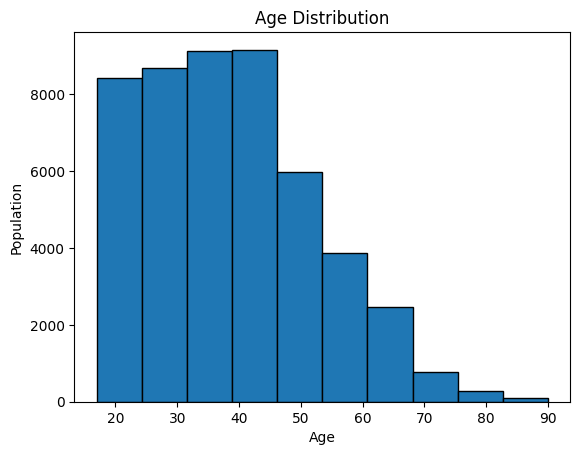

In [33]:
import matplotlib.pyplot as plt

plt.hist(Adults['age'],bins=10,edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Population')
plt.title('Age Distribution')
plt.show()

o Is the distribution Symmetrical, Right-Skewed, or Left-Skewed?


The distribution of Age is right skewed because the most of the population is clustered towards the left. Most people cluster in the younger ranges of 20-40 while the less population are older.

o How might a skewed age distribution affect an AI's ability to understand older vs.
    younger populations?

For our dataset, the Ai would see most of the sample data having younger ages (20-40) and would see very few examples of adults that are 60+. Because of this, the model would become an expert on young people but quite ignorant about older people leading to poor predictions for adults

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


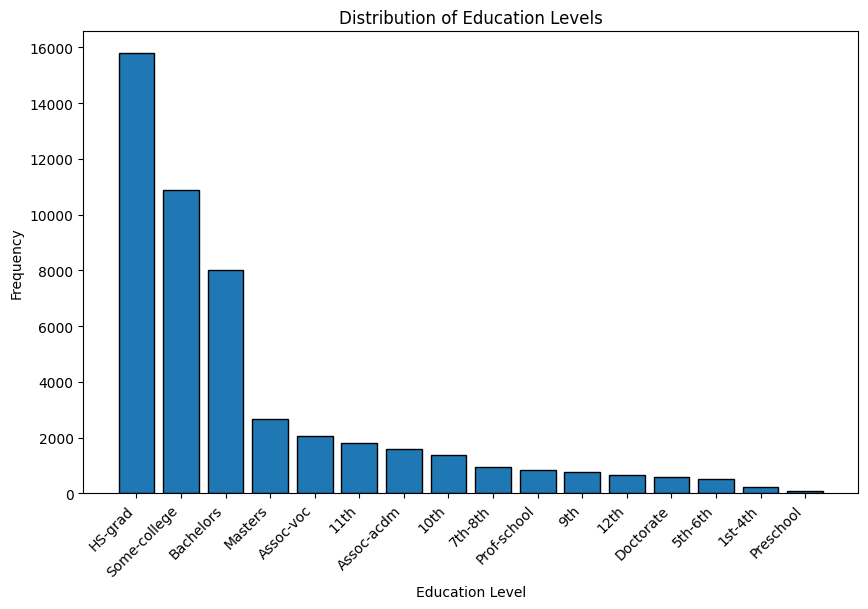

In [30]:
Education = Adults['education'].value_counts()
print(Education)

plt.figure(figsize=(10, 6))
plt.bar(Education.index, Education.values, edgecolor='black')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.title('Distribution of Education Levels')
plt.xticks(rotation=45, ha='right')  # i had to rotate the labels for readbability
plt.show()

o Identify the "Majority Class" (the most common education level).

HS-Grad is the majority class

Identify a "Rare Category" (an education level with very few entries). Should rare categories be grouped into an "Other" category? Why or why not?

Preschool is a rare category. And No, they should not be grouped as Other because:

- Sample vs. Population: This is only sample data. The population itself might have more people at the preschool education level.
- Meaningful Category: Even if rare, the "Preschool" level represents a distinct education level that could have unique income patterns.